In [1]:
from sklearn.model_selection import train_test_split

In [2]:
import pandas as pd

C:\Users\Sriram Satvik\AppData\Local\Temp\ipykernel_11812\4080736814.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
df=pd.read_csv('../data/processed/features_clean.csv')

In [4]:
df.head()

,url_length,domain_length,path_length,num_dots,num_hyphens,num_underscores,num_slashes,num_digits_in_url,num_subdomains,has_https,has_http,domain_entropy,url_entropy,path_entropy,num_brand_keywords,path_depth,num_domain_tokens,longest_domain_token,label
0,23,15,0,2,0,0,2,0,1,1,0,3.3232,3.8820,0.0000,0,0,3,7,0
1,43,12,23,1,0,0,5,11,0,1,0,3.5850,4.6271,3.9362,0,3,1,3,1
2,32,24,0,2,0,0,2,0,1,1,0,3.5739,3.9292,0.0000,0,0,3,16,0
3,38,17,13,3,0,0,3,0,1,1,0,3.4548,4.2539,3.5466,0,1,3,7,1
4,116,20,14,5,0,3,3,4,1,0,1,3.3464,4.5853,3.2359,0,1,3,13,0


In [5]:
df.shape

(353406, 19)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 353406 entries, 0 to 353405
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   url_length            353406 non-null  int64  
 1   domain_length         353406 non-null  int64  
 2   path_length           353406 non-null  int64  
 3   num_dots              353406 non-null  int64  
 4   num_hyphens           353406 non-null  int64  
 5   num_underscores       353406 non-null  int64  
 6   num_slashes           353406 non-null  int64  
 7   num_digits_in_url     353406 non-null  int64  
 8   num_subdomains        353406 non-null  int64  
 9   has_https             353406 non-null  int64  
 10  has_http              353406 non-null  int64  
 11  domain_entropy        353406 non-null  float64
 12  url_entropy           353406 non-null  float64
 13  path_entropy          353406 non-null  float64
 14  num_brand_keywords    353406 non-null  int64  
 15  

In [11]:
x_tmp, x_test, y_tmp, y_test = train_test_split(df.drop(columns=['label'], axis=1), df['label'], test_size=0.2, random_state=42, stratify=df['label'])

In [12]:
x_train, x_val, y_train, y_val = train_test_split(x_tmp, y_tmp, test_size=0.25, random_state=42, stratify=y_tmp)

In [13]:
x_train.shape

(212043, 18)

In [14]:
x_val.shape

(70681, 18)

In [15]:
x_test.shape

(70682, 18)

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [19]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000),
    "Decision Tree"       : DecisionTreeClassifier(random_state=42),
    "Random Forest"       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost"             : XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
}

In [21]:
results = []
for name, model in models.items():
    print(f"Training {name}...", end=" ", flush=True)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_val)
    results.append({
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_val, y_pred) * 100, 2),
        "Precision" : round(precision_score(y_val, y_pred) * 100, 2),
        "Recall"    : round(recall_score(y_val, y_pred) * 100, 2),
        "F1"        : round(f1_score(y_val, y_pred) * 100, 2),
    })
    print(f"F1: {results[-1]['F1']}%")

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
print("\n")
print(results_df.to_string(index=False))

Training Logistic Regression... F1: 84.68%
Training Decision Tree... 

c:\Users\Sriram Satvik\Desktop\PhishGuard\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


F1: 93.36%
Training Random Forest... F1: 95.22%
Training XGBoost... F1: 95.11%


              Model  Accuracy  Precision  Recall    F1
      Random Forest     95.20      94.94   95.50 95.22
            XGBoost     95.08      94.65   95.57 95.11
      Decision Tree     93.37      93.49   93.23 93.36
Logistic Regression     83.99      81.19   88.48 84.68


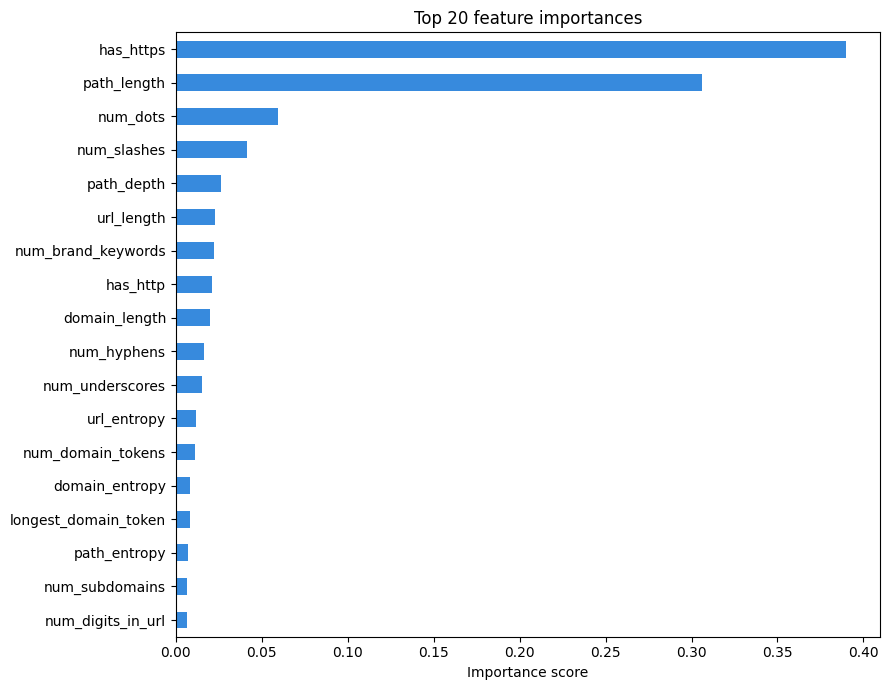

In [23]:
import matplotlib.pyplot as plt

# Assuming XGBoost came out on top
best = models["XGBoost"]

importances = pd.Series(
    best.feature_importances_,
    index=x_train.columns
).sort_values(ascending=True).tail(20)

plt.figure(figsize=(9, 7))
importances.plot(kind="barh", color="#378ADD")
plt.title("Top 20 feature importances")
plt.xlabel("Importance score")
plt.tight_layout()
plt.show()

# Drop features with near-zero importance
weak = importances[importances < 0.005].index.tolist()
if weak:
    print(f"Dropping weak features: {weak}")
    x_train = x_train.drop(columns=weak)
    x_val   = x_val.drop(columns=weak)
    x_test  = x_test.drop(columns=weak)

In [25]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators"  : [100, 200, 300],
    "max_depth"     : [3, 5, 7],
    "learning_rate" : [0.05, 0.1, 0.2],
    "subsample"     : [0.8, 1.0],
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid.fit(x_train, y_train)
print("Best params :", grid.best_params_)
print("Best CV F1  :", round(grid.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best params : {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300, 'subsample': 1.0}
Best CV F1  : 95.41 %


In [38]:
tmp=XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, n_estimators=400, max_depth=9, learning_rate=0.2, subsample=1)

In [39]:
tmp.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [40]:
y_pred = tmp.predict(x_val)

In [41]:
accuracy_score(y_val, y_pred)

0.9548252005489453

In [42]:
tmp=XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, n_estimators=400, max_depth=11, learning_rate=0.2, subsample=1)

In [43]:
tmp.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=11,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [44]:
y_pred = tmp.predict(x_val)

In [45]:
accuracy_score(y_val, y_pred)

0.9533962451012294

In [46]:
tmp=XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, n_estimators=500, max_depth=9, learning_rate=0.2, subsample=1)

In [47]:
tmp.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [48]:
y_pred = tmp.predict(x_val)

In [49]:
accuracy_score(y_val, y_pred)

0.9541177968619572

In [50]:
final_model = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1, n_estimators=400, max_depth=9, learning_rate=0.2, subsample=1)

In [52]:
final_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [53]:
y_pred_test = final_model.predict(x_test)

=== FINAL TEST SET RESULTS ===
              precision    recall  f1-score   support

  Legitimate       0.96      0.95      0.96     35341
    Phishing       0.95      0.96      0.96     35341

    accuracy                           0.96     70682
   macro avg       0.96      0.96      0.96     70682
weighted avg       0.96      0.96      0.96     70682



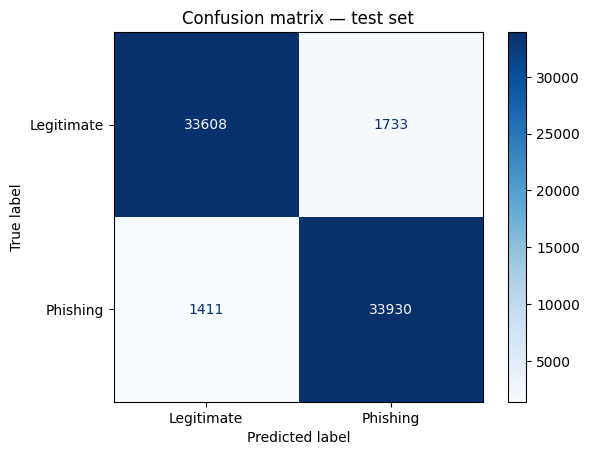

In [55]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

final_model = grid.best_estimator_
y_pred_test = final_model.predict(x_test)

print("=== FINAL TEST SET RESULTS ===")
print(classification_report(y_test, y_pred_test,
      target_names=["Legitimate", "Phishing"]))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=["Legitimate", "Phishing"],
    cmap="Blues"
)
plt.title("Confusion matrix — test set")
plt.show()

In [56]:
import joblib
import os

joblib.dump(final_model, '../models/final_model.pkl')

feature_names = x_train.columns.to_list()
joblib.dump(feature_names, '../models/feature_names.pkl')

print("done")
print(feature_names)


done
['url_length', 'domain_length', 'path_length', 'num_dots', 'num_hyphens', 'num_underscores', 'num_slashes', 'num_digits_in_url', 'num_subdomains', 'has_https', 'has_http', 'domain_entropy', 'url_entropy', 'path_entropy', 'num_brand_keywords', 'path_depth', 'num_domain_tokens', 'longest_domain_token']


In [57]:
len(feature_names)

18

In [1]:
import fastapi
import uvicorn
import whois
import dns.resolver
import dotenv
import requests
import joblib
import pandas
import sklearn
import xgboost
print('All imports successful')

C:\Users\Sriram Satvik\AppData\Local\Temp\ipykernel_15804\3701675076.py:8: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas


All imports successful


In [1]:
import joblib
import xgboost as xgb

# Load your existing model
model = joblib.load("../models/final_model.pkl")

# Save in XGBoost native format — version independent
model.save_model("../models/final_model.json")

print("Model saved in native XGBoost format")

Model saved in native XGBoost format
